# 01-logistic-regression-bank-marketing-campaign

**1. CARGA DEL DATASET**

In [2]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
# CARGO LOS DATOS
url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
total_data = pd.read_csv(url, sep=";")
total_data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [4]:
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
total_data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [6]:
total_data.shape

(41188, 21)

In [7]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [8]:
total_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

- El dataset contiene 41.188 filas y 21 columnas relacionadas con una campaña de marketing bancario.
- Incluye variables relacionnadas con los clientes del banco como su edad, tipo de trabajo, estado civil y nivel de educación.
- El objetivo es identificar a los clientes que tienen una mayor probabilidad de contratar un depósito a largo plazo.

In [9]:
# TODOS LOS VALORES FALTANTES DEL DATAFRAME
total_data.isna().sum().sum()

np.int64(0)

In [10]:
# CUENTO LOS VALORES NULOS PARA CADA COLUMNA
total_data.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [11]:
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending=False)

age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64

In [12]:
total_data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [13]:
# POSIBLES DATOS CATEGÓRICOS
total_data.select_dtypes(include=['object']).columns

/tmp/ipykernel_54651/1623080498.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  total_data.select_dtypes(include=['object']).columns


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')

**2. LIMPIEZA INICIAL**

In [14]:
total_data['y'].duplicated().sum()

np.int64(41186)

In [15]:
total_data[total_data['y'].duplicated() == True]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [16]:
# Esto me dice cuántos clientes aceptan y cuántos no
total_data['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

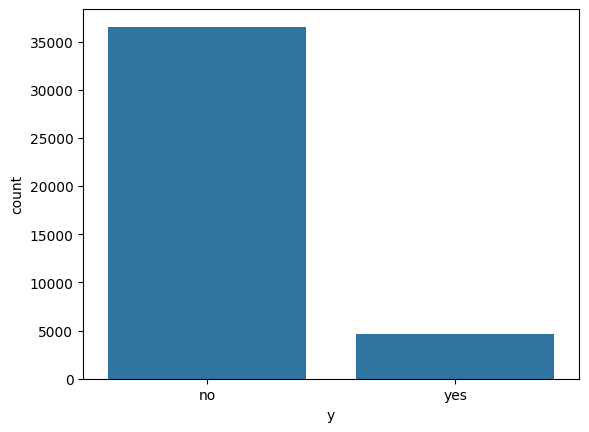

In [17]:
sns.countplot(data=total_data, x="y")
plt.show()

In [18]:
# ELIMINO LAS COLUMNAS QUE DECIDÍ ELIMINAR
total_data.drop(columns=['month','day_of_week','duration','pdays', 'nr.employed'], inplace=True)
total_data = total_data.dropna().reset_index(drop=True)
total_data.head()

,age,job,marital,education,default,housing,loan,contact,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857,no
1,57,services,married,high.school,unknown,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857,no
2,37,services,married,high.school,no,yes,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857,no
3,40,admin.,married,basic.6y,no,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857,no
4,56,services,married,high.school,no,no,yes,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857,no


In [19]:
total_data.shape

(41188, 16)

In [20]:
total_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'campaign', 'previous', 'poutcome', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'y'],
      dtype='str')

- Las variables 'month' y 'day of week' se eliminaron porque representan únicamente el momento del contacto y probablemente no influyen directamente en la decisión del cliente.
- La variable 'duration' se eliminó porque representa la duración de la llamada telefónica y solo se conoce después del contacto con el cliente, por lo que no se producirían predicciones reales.
- La variable 'pdays' se eliminó porque la mayoría de los valores corresponden a un mismo valor (999), lo que indica que el cliente no fue contactado previamente.
- La variable 'nr.employed' se eliminó para evitar redundancias con otros indicadores económicos del dataset y simplificar el modelo.

**3. ANÁLISIS DE VARIABLES**

- Variables categóricas: 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'y'
- Variables numéricas: 'age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m'
- Variables eliminadas: 'month','day_of_week','duration','pdays', 'nr.employed'

**Variables categóricas**

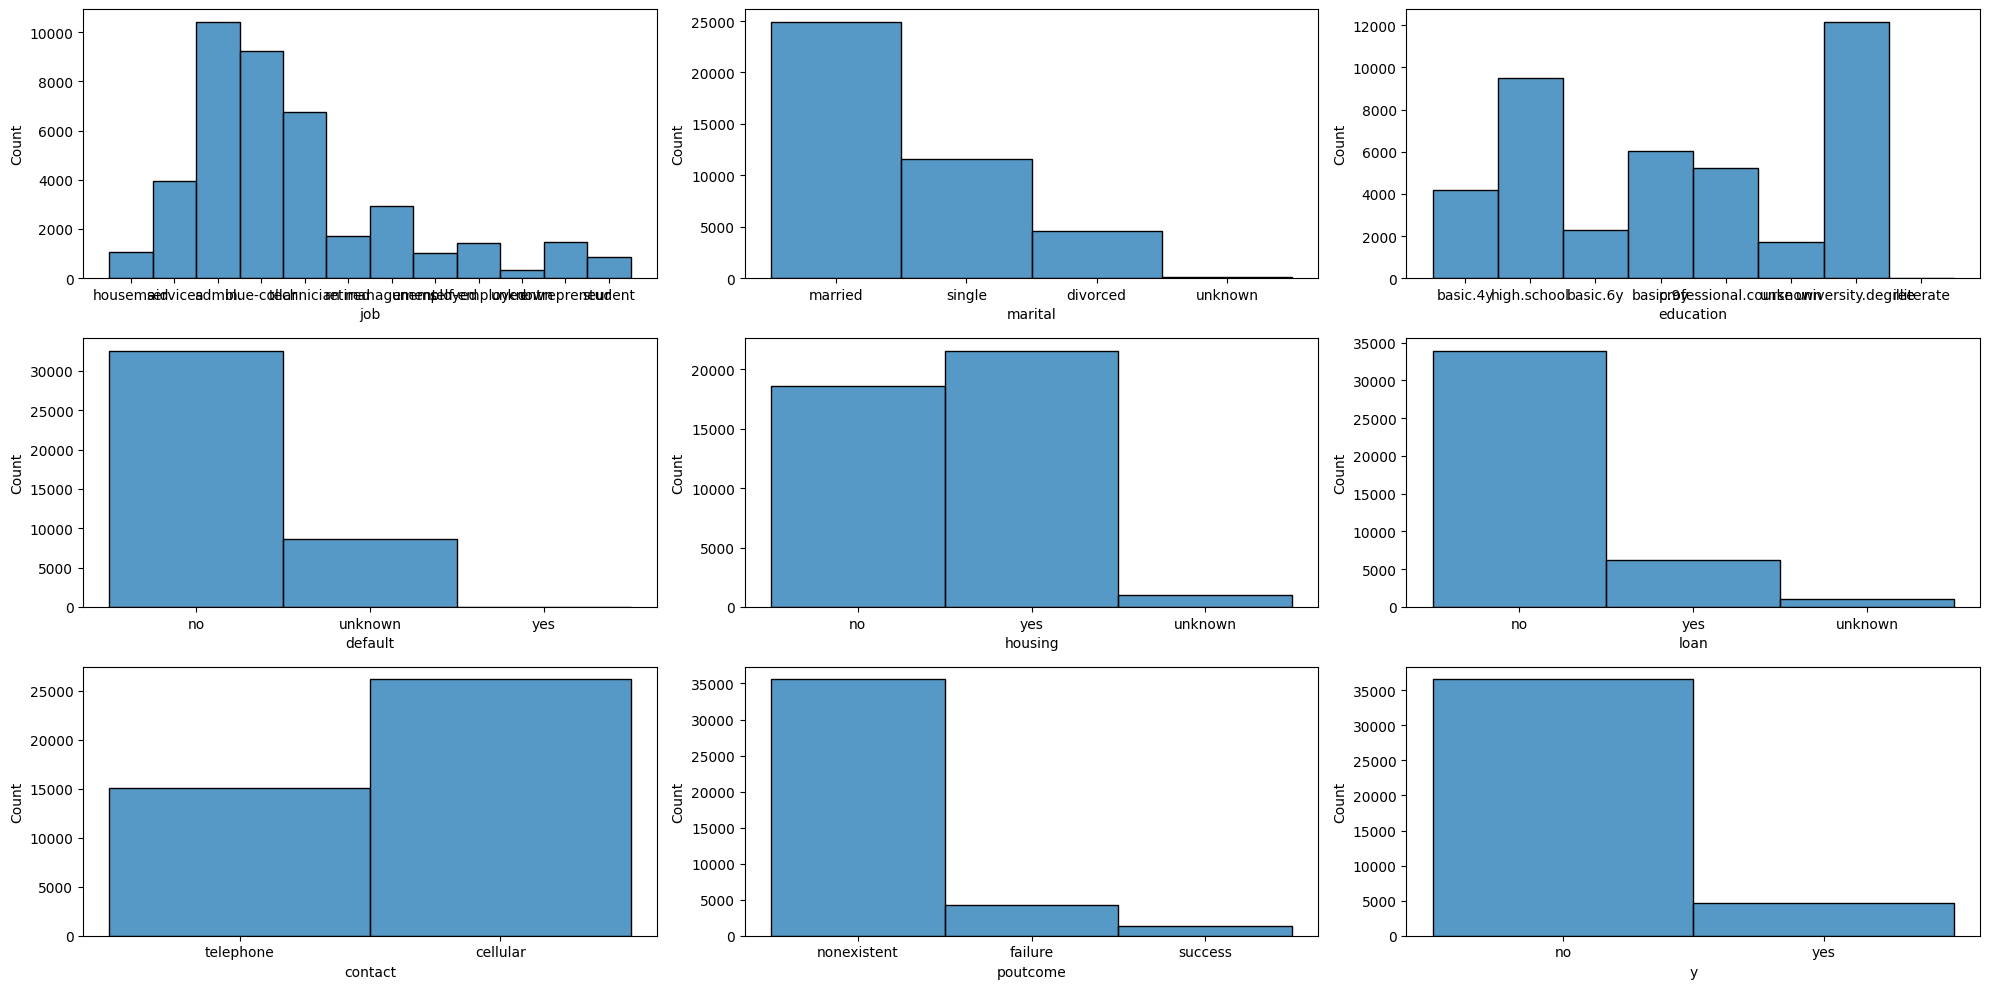

In [23]:
# HISTOGRA MÚLTIPLE
fig, axis = plt.subplots(3, 3, figsize=(20, 10))

sns.histplot(data=total_data, x='job', ax=axis[0,0])
sns.histplot(data=total_data, x='marital', ax=axis[0,1])
sns.histplot(data=total_data, x='education', ax=axis[0,2])

sns.histplot(data=total_data, x='default', ax=axis[1,0])
sns.histplot(data=total_data, x='housing', ax=axis[1,1])
sns.histplot(data=total_data, x='loan', ax=axis[1, 2])

sns.histplot(data=total_data, x='contact', ax=axis[2,0])
sns.histplot(data=total_data, x='poutcome', ax=axis[2,1])
sns.histplot(data=total_data, x='y', ax=axis[2,2])

plt.tight_layout()
plt.show()

**Variables numéricas**

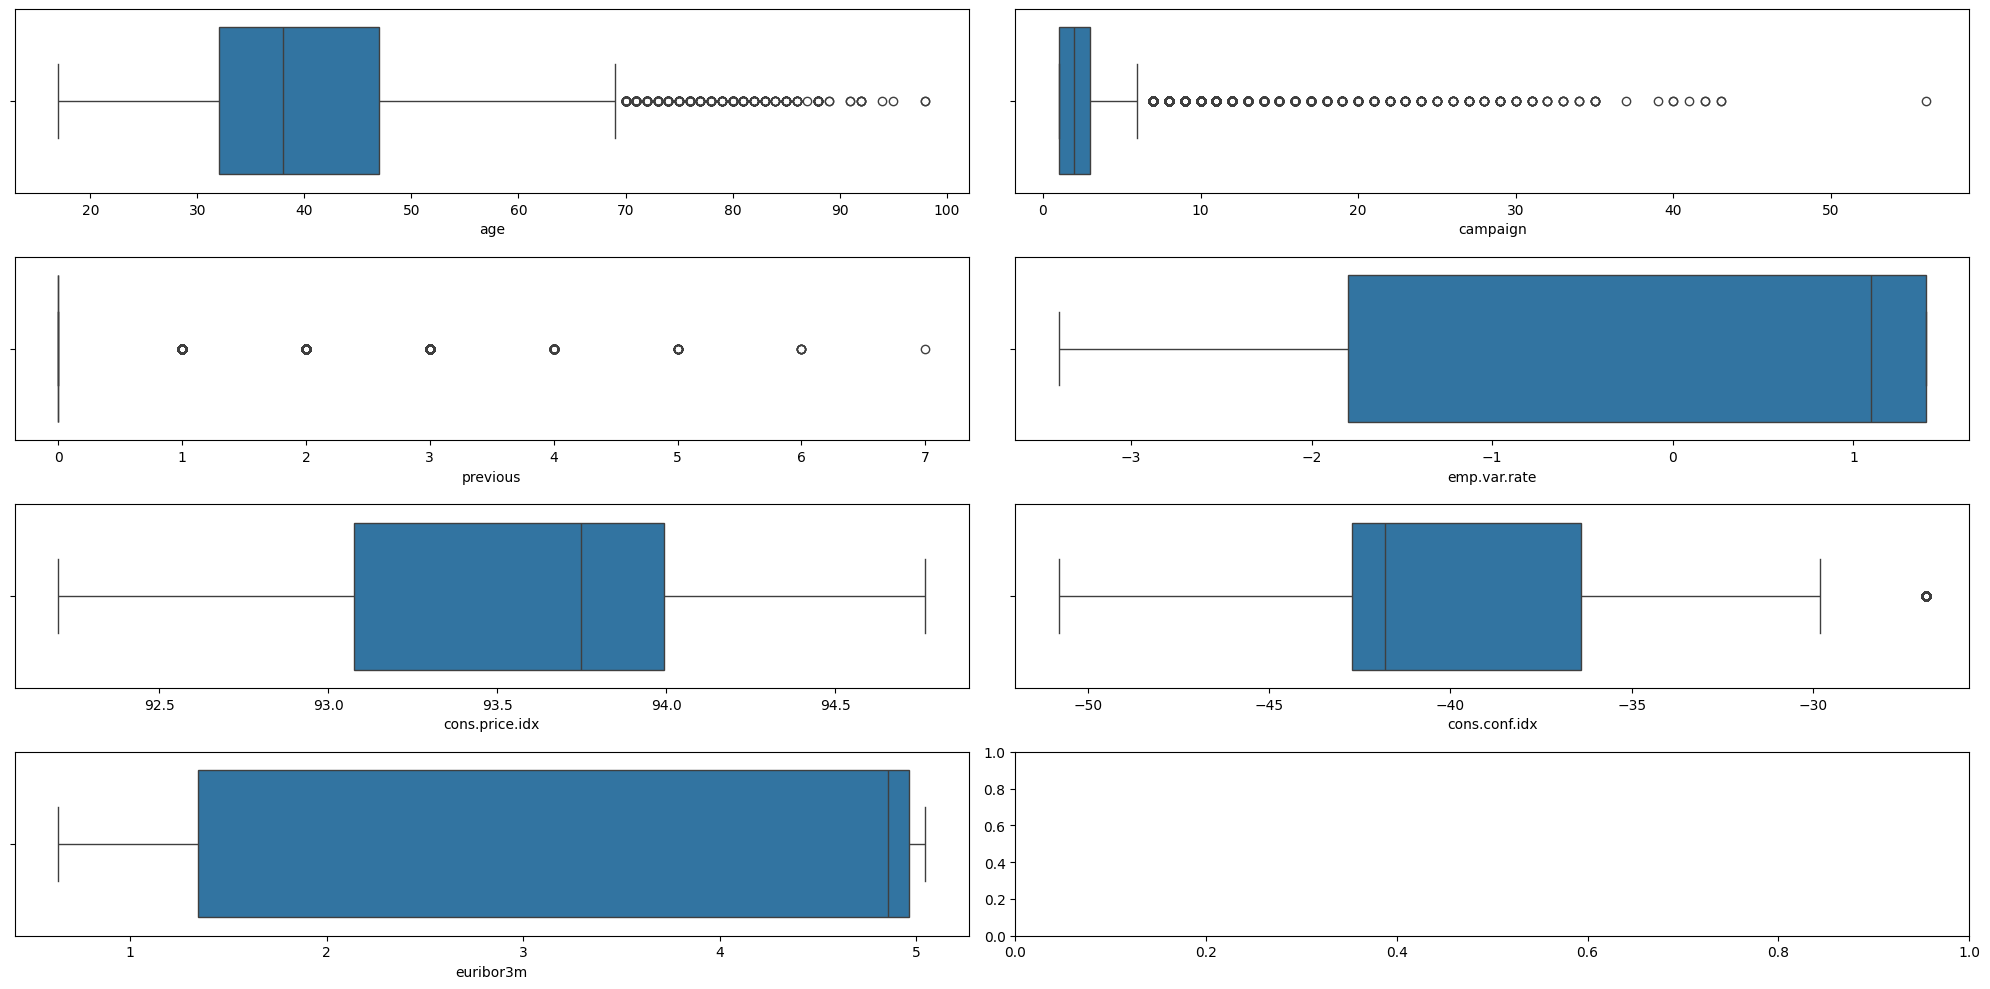

In [25]:
fig, axis = plt.subplots(4, 2, figsize = (20, 10))

sns.boxplot(ax = axis[0, 0], x = total_data["age"])
sns.boxplot(ax = axis[0, 1], x = total_data["campaign"])

sns.boxplot(ax = axis[1, 0], x = total_data["previous"])
sns.boxplot(ax = axis[1, 1], x = total_data["emp.var.rate"])

sns.boxplot(ax = axis[2, 0], x = total_data["cons.price.idx"])
sns.boxplot(ax = axis[2, 1], x = total_data["cons.conf.idx"])

sns.boxplot(ax = axis[3, 0], x = total_data["euribor3m"])

plt.tight_layout()
plt.show()

**4. RELACIONES ENTRE VARIABLES**

**Análisis numérico-numérico**